# PyTorch dataset template

In [10]:
# Must be set BEFORE torch is imported: cuBLAS reads this once, when it initializes, so
# setting it later has no effect. It is what lets training.deterministic work without a
# cuBLAS warning on every run. (Restart the kernel if torch was already imported.)
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import numpy as np
import sys
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import sunpy.visualization.colormaps as cm
import matplotlib.gridspec as gridspec

import yaml

# Append base path.  May need to be modified if the folder structure changes.
# It gives the notebook access to the wokshop_infrastructure folder.
sys.path.append("../../")
 
# Append Surya path. May need to be modified if the folder structure changes.
# It gives the notebook access to surya's release code.

from workshop_infrastructure.utils import build_scalers  # Data scaling utilities for Surya stacks

## Load configuration


In [11]:
# The config is the single source of truth. load_flare_config() parses it into a typed
# object, exactly as the training script 3_finetune_template_1D.py does, so the same YAML
# behaves identically in the notebook and in production.
#
# Typed means: cfg.data.channels instead of config["data"]["channels"] — you get IDE
# completion, and a misspelled key fails here with a list of the valid ones instead of
# silently doing nothing.
from downstream_apps.template.configs import load_flare_config

cfg = load_flare_config("./configs/config_script.yaml")
print(f"Loaded config for job: {cfg.job_id}")

# Paths in the YAML are relative to the config file, and come back resolved:
print(f"  train index : {cfg.data.train_data_path}")
print(f"  scalers     : {cfg.data.scalers_path}")


Loaded config for job: solar_flare_forecasting
  train index : /home/jovyan/tmp/surya_workshop/data/indices/surya_aws_s3_train.csv
  scalers     : /home/jovyan/tmp/surya_workshop/downstream_apps/flare_forecast/assets/scalers.yaml


## Download assets



In [12]:
# One implementation, shared by the notebooks, the training script and the
# download_*.sh wrappers: workshop_infrastructure/assets.py.
# This notebook only needs the scalers - no backbone is loaded.
from workshop_infrastructure.assets import ensure_assets

ensure_assets(cfg, which=["scalers"])

# Now that scalers.yaml is guaranteed to be on disk, load it. build_scalers()
# accepts the resolved path directly.
scalers = build_scalers(info=cfg.data.scalers_path)
print(f"Loaded scalers for {len(scalers)} channels.")


Loaded scalers for 13 channels.


## Define DS dataset

In [13]:
from downstream_apps.flare_forecast.datasets.flare_dataset import flare_Dataset

## Initialize class with Surya stacks



In [5]:
train_dataset = flare_Dataset(
    #### All these lines are required by the parent HelioNetCDFDataset class
    index_path=cfg.data.train_data_path,
    time_delta_input_minutes=cfg.data.time_delta_input_minutes,
    time_delta_target_minutes=cfg.data.time_delta_target_minutes,
    n_input_timestamps=cfg.model.time_embedding.time_dim,
    rollout_steps=cfg.rollout_steps,
    channels=cfg.data.channels,
    drop_hmi_probability=cfg.drop_hmi_probability,
    use_latitude_in_learned_flow=cfg.use_latitude_in_learned_flow,
    scalers=scalers,
    phase="train",          # "val" disables random channel masking and flips
    # How s3:// paths in the index are read: "download" (default) | "simplecache" | "stream".
    # "download" fetches each file into s3_cache_dir first — recommended for NetCDF.
    s3_mode=cfg.data.s3_mode,
    s3_storage_options={"anon": cfg.data.s3_anon},
    s3_cache_dir=cfg.data.s3_cache_dir,
    #### Put your downstream (DS) specific parameters below this line
    return_surya_stack=True,
    max_number_of_samples=6,
    ds_flare_index_path=cfg.data.flare_index_path,
    ds_time_column=cfg.data.ds_time_column,
    ds_time_tolerance=cfg.data.ds_time_tolerance,
    ds_match_direction=cfg.data.ds_match_direction,
)

# Notebooks 1 and 2 skip this block entirely: build_helio_dataloaders() in
# workshop_infrastructure/datasets/builders.py fills in everything above the
# "downstream specific" line straight from the config.


In [6]:
item = train_dataset.__getitem__(0)
item.keys()

In [7]:
item['ts'].shape

## Plotting input stack



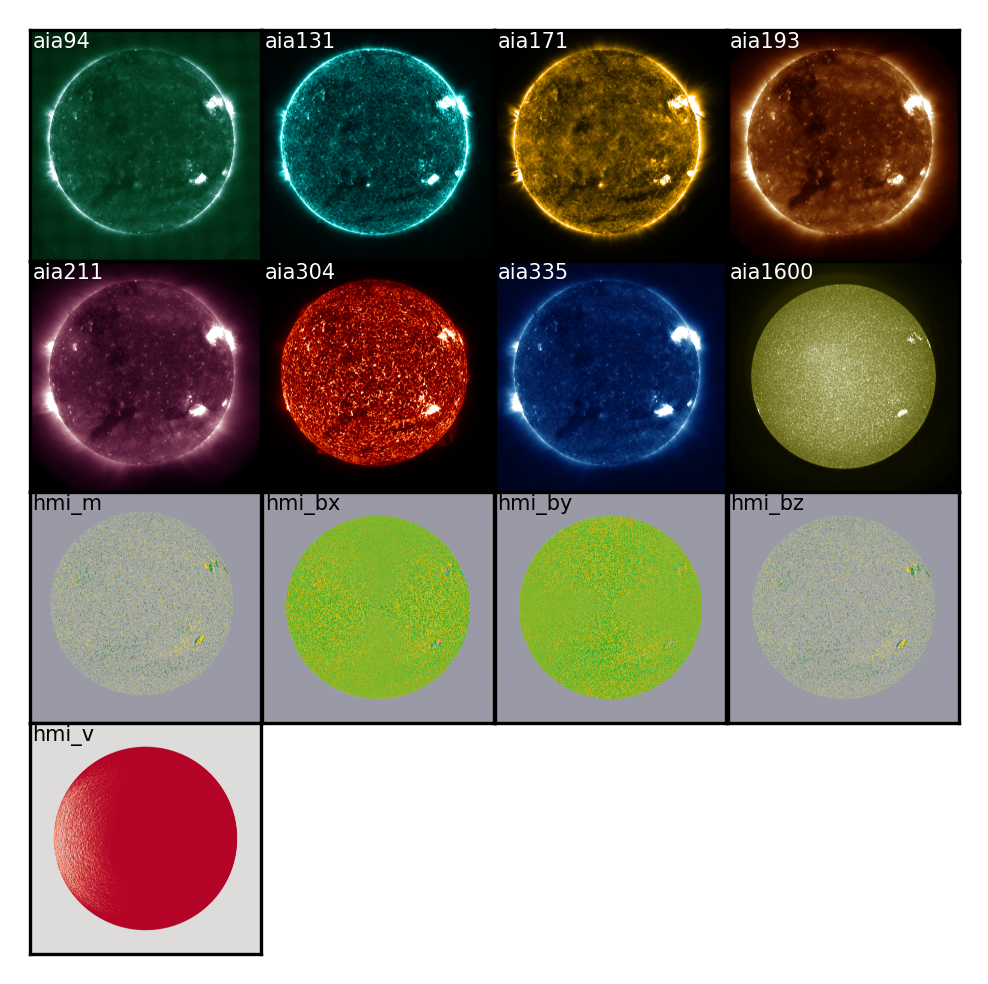

In [16]:
unnormalized_ts = train_dataset.inverse_transform_data(item['ts'][:,0,...])
channel_order = cfg.data.channels
fig = plt.figure(figsize=np.array([4,4]), dpi=300)
gs = gridspec.GridSpec(4, 4, figure=fig, wspace=0, hspace=0)

limits = {}

for i in range(4):
    for j in range(4):
        n = i*4 + j
        if n < len(channel_order):

            ax = fig.add_subplot(gs[i,j])
            channel = channel_order[n]
            if 'hmi' not in channel:
                lim = np.percentile(unnormalized_ts[n,...][unnormalized_ts[n,...]!=0], 99)
                ax.imshow(unnormalized_ts[n,...], cmap=f'sdo{channel}', vmin=0, vmax=lim)
                font_color = 'w'

            else:
                font_color = 'k'
                if "_v" not in channel:
                    lim = 1000
                    ax.imshow(unnormalized_ts[n,...], cmap=f'hmimag', vmin = -lim, vmax=lim)
                else:
                    lim = 1000
                    ax.imshow(unnormalized_ts[n,...], cmap=f'coolwarm', vmin = -lim, vmax=lim)                    

            ax.text(0.01, 0.99, channel, transform=ax.transAxes, horizontalalignment='left', verticalalignment='top', color=font_color, fontsize=5)  
            ax.set_xticks([])
            ax.set_yticks([])             


## testing input edits
plotting inputs and what will be forecasted, as side by side images. 2 inputs, 1 prediction, 1 hr apart.

also a bunch of other checks too.

In [9]:
item = train_dataset.__getitem__(0)
print(item['forecast'])       # scalar label, e.g. array(0.42, dtype=float32)
print(item['flipped'].shape)  # image stack, e.g. (13, 2, 4096, 4096)

[[[[-1.2724411e-02  3.2728739e-02 -4.3346462e-01 ... -5.4036492e-01
    -5.4036492e-01 -5.4036492e-01]
   [-6.0500924e-02  6.6612132e-02 -4.1380355e-01 ... -5.4036492e-01
    -5.4036492e-01 -5.4036492e-01]
   [-2.5764897e-01 -5.1902348e-01 -1.6739714e-01 ... -5.4036492e-01
    -5.4036492e-01 -5.4036492e-01]
   ...
   [-2.1651629e-01 -2.8244001e-01 -4.6158609e-01 ... -5.4036492e-01
    -5.4036492e-01 -5.4036492e-01]
   [-2.1651626e-01 -6.8018571e-02 -2.7390328e-01 ... -5.4036492e-01
    -5.4036492e-01 -5.4036492e-01]
   [-5.4036492e-01 -5.4036492e-01 -5.4036492e-01 ... -5.4036492e-01
    -5.4036492e-01 -5.4036492e-01]]]


 [[[-6.4856654e-01 -7.0937878e-01 -6.9909859e-01 ... -6.8126714e-01
    -6.8294162e-01 -6.8294162e-01]
   [-6.9535953e-01 -6.7359805e-01 -6.6239804e-01 ... -6.8289977e-01
    -6.5019375e-01 -6.5019375e-01]
   [-6.9231117e-01 -6.7153740e-01 -7.0559412e-01 ... -6.9695300e-01
    -6.6191530e-01 -6.6761732e-01]
   ...
   [-6.7778182e-01 -6.8425459e-01 -6.9025886e-01 ... -7

KeyError: 'flipped'

In [10]:
print('ts' in item, 'flipped' in item)

True False


Frame timestamps: [Timestamp('2010-06-11 23:30:00'), Timestamp('2010-06-12 00:30:00')]


t=0 timestamp=2010-06-11 23:30:00 min=0.0000 max=266.1827 mean=0.6032


t=1 timestamp=2010-06-12 00:30:00 min=0.0000 max=318.2239 mean=0.6121


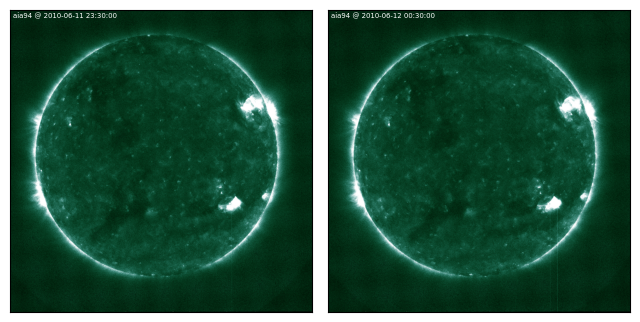

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

anchor_time = pd.Timestamp(item['ds_index'])
input_offsets = cfg.data.time_delta_input_minutes
frame_timestamps = [anchor_time + pd.Timedelta(minutes=off) for off in input_offsets]
print("Frame timestamps:", frame_timestamps)

n = 0
channel_order = cfg.data.channels
channel = channel_order[n]
n_timesteps = item['ts'].shape[1]

fig = plt.figure(figsize=np.array([4 * n_timesteps, 4]), dpi=100)
gs = gridspec.GridSpec(1, n_timesteps, figure=fig, wspace=0.05, hspace=0)

for t in range(n_timesteps):
    ts_frame = train_dataset.inverse_transform_data(item['ts'][:, t, ...])
    plot_ts = ts_frame[n, ...]
    print(f"t={t} timestamp={frame_timestamps[t]} min={plot_ts.min():.4f} max={plot_ts.max():.4f} mean={plot_ts.mean():.4f}")

    ax = fig.add_subplot(gs[0, t])
    if 'hmi' not in channel:
        lim = np.percentile(plot_ts[plot_ts != 0], 99)
        ax.imshow(plot_ts, cmap=f'sdo{channel}', vmin=0, vmax=lim)
        font_color = 'w'
    else:
        font_color = 'k'
        lim = 1000
        if "_v" not in channel:
            ax.imshow(plot_ts, cmap='hmimag', vmin=-lim, vmax=lim)
        else:
            ax.imshow(plot_ts, cmap='coolwarm', vmin=-lim, vmax=lim)

    label = f"{channel} @ {frame_timestamps[t]}"
    ax.text(0.01, 0.99, label, transform=ax.transAxes,
            horizontalalignment='left', verticalalignment='top',
            color=font_color, fontsize=5)
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

In [9]:
item = train_dataset.__getitem__(0)


In [10]:
print(item['forecast'])
print(item['forecast'].shape)
print('forecast_label' in item)

[[[[-1.2724411e-02  3.2728739e-02 -4.3346462e-01 ... -5.4036492e-01
    -5.4036492e-01 -5.4036492e-01]
   [-6.0500924e-02  6.6612132e-02 -4.1380355e-01 ... -5.4036492e-01
    -5.4036492e-01 -5.4036492e-01]
   [-2.5764897e-01 -5.1902348e-01 -1.6739714e-01 ... -5.4036492e-01
    -5.4036492e-01 -5.4036492e-01]
   ...
   [-2.1651629e-01 -2.8244001e-01 -4.6158609e-01 ... -5.4036492e-01
    -5.4036492e-01 -5.4036492e-01]
   [-2.1651626e-01 -6.8018571e-02 -2.7390328e-01 ... -5.4036492e-01
    -5.4036492e-01 -5.4036492e-01]
   [-5.4036492e-01 -5.4036492e-01 -5.4036492e-01 ... -5.4036492e-01
    -5.4036492e-01 -5.4036492e-01]]]


 [[[-6.4856654e-01 -7.0937878e-01 -6.9909859e-01 ... -6.8126714e-01
    -6.8294162e-01 -6.8294162e-01]
   [-6.9535953e-01 -6.7359805e-01 -6.6239804e-01 ... -6.8289977e-01
    -6.5019375e-01 -6.5019375e-01]
   [-6.9231117e-01 -6.7153740e-01 -7.0559412e-01 ... -6.9695300e-01
    -6.6191530e-01 -6.6761732e-01]
   ...
   [-6.7778182e-01 -6.8425459e-01 -6.9025886e-01 ... -7

In [11]:
print(train_dataset.return_surya_stack)

True


In [12]:
print(train_dataset.return_surya_stack)
print(train_dataset.load_forecast_frames)
print(item.keys())
print(item['forecast'].shape)

True
True
dict_keys(['ts', 'time_delta_input', 'forecast', 'lead_time_delta', 'ground_truth', 'ds_index', 'was_flipped'])
(13, 1, 4096, 4096)


Input timestamps: [Timestamp('2010-06-11 23:30:00'), Timestamp('2010-06-12 00:30:00')]
Forecast timestamps: [Timestamp('2010-06-12 01:30:00')]


[input]  t=0 timestamp=2010-06-11 23:30:00 min=0.0000 max=266.1827 mean=0.6032


[input]  t=1 timestamp=2010-06-12 00:30:00 min=0.0000 max=318.2239 mean=0.6121


[ground_truth] l=0 timestamp=2010-06-12 01:30:00 min=0.0000 max=2054.6917 mean=0.6320


/tmp/ipykernel_76/615703746.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


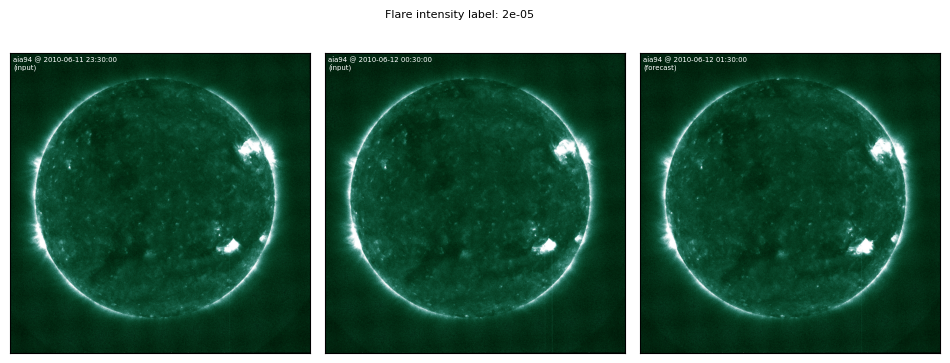

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

anchor_time = pd.Timestamp(item['ds_index'])
input_offsets = cfg.data.time_delta_input_minutes
frame_timestamps = [anchor_time + pd.Timedelta(minutes=off) for off in input_offsets]
print("Input timestamps:", frame_timestamps)

target_offsets = cfg.data.time_delta_target_minutes
n_lead_steps = item['forecast'].shape[1]
target_timestamps = [anchor_time + pd.Timedelta(minutes=target_offsets * (l + 1)) for l in range(n_lead_steps)]
print("Forecast timestamps:", target_timestamps)

n = 0
channel_order = cfg.data.channels
channel = channel_order[n]
n_timesteps = item['ts'].shape[1]

n_cols = n_timesteps + n_lead_steps
fig = plt.figure(figsize=np.array([4 * n_cols, 4]), dpi=100)
gs = gridspec.GridSpec(1, n_cols, figure=fig, wspace=0.05, hspace=0)

def plot_frame(ax, plot_ts, label):
    if 'hmi' not in channel:
        lim = np.percentile(plot_ts[plot_ts != 0], 99)
        ax.imshow(plot_ts, cmap=f'sdo{channel}', vmin=0, vmax=lim)
        font_color = 'w'
    else:
        font_color = 'k'
        lim = 1000
        if "_v" not in channel:
            ax.imshow(plot_ts, cmap='hmimag', vmin=-lim, vmax=lim)
        else:
            ax.imshow(plot_ts, cmap='coolwarm', vmin=-lim, vmax=lim)
    ax.text(0.01, 0.99, label, transform=ax.transAxes,
            horizontalalignment='left', verticalalignment='top',
            color=font_color, fontsize=5)
    ax.set_xticks([])
    ax.set_yticks([])

for t in range(n_timesteps):
    ts_frame = train_dataset.inverse_transform_data(item['ts'][:, t, ...])
    plot_ts = ts_frame[n, ...]
    print(f"[input]  t={t} timestamp={frame_timestamps[t]} min={plot_ts.min():.4f} max={plot_ts.max():.4f} mean={plot_ts.mean():.4f}")
    ax = fig.add_subplot(gs[0, t])
    plot_frame(ax, plot_ts, f"{channel} @ {frame_timestamps[t]}\n(input)")

for l in range(n_lead_steps):
    forecast_frame = train_dataset.inverse_transform_data(item['forecast'][:, l, ...])
    plot_ts = forecast_frame[n, ...]
    print(f"[ground_truth] l={l} timestamp={target_timestamps[l]} min={plot_ts.min():.4f} max={plot_ts.max():.4f} mean={plot_ts.mean():.4f}")
    ax = fig.add_subplot(gs[0, n_timesteps + l])
    plot_frame(ax, plot_ts, f"{channel} @ {target_timestamps[l]}\n(forecast)")

fig.suptitle(f"Flare intensity label: {float(item['ground_truth']):.4g}", fontsize=8)
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

flare_catalog = pd.read_csv(cfg.data.flare_index_path)
flare_catalog['start_time'] = pd.to_datetime(flare_catalog['start_time'])
flare_catalog['end_time'] = pd.to_datetime(flare_catalog['end_time'])

event_time = pd.Timestamp(item['ds_index'])

match = flare_catalog[
    (flare_catalog['start_time'] <= event_time) &
    (flare_catalog['end_time'] >= event_time)
]

if not match.empty:
    print(f"Flare in progress at {event_time}:")
    print(match[['start_time', 'peak_time', 'end_time', 'GOES_class']])
else:
    print(f"No flare in progress at {event_time} (nearest events below):")
    nearest = flare_catalog.iloc[(flare_catalog['start_time'] - event_time).abs().argsort()[:3]]
    print(nearest[['start_time', 'peak_time', 'end_time', 'GOES_class']])

Flare in progress at 2010-06-12 00:30:00:
               start_time            peak_time            end_time GOES_class
49292 2010-06-12 00:30:00  2010-06-12T00:57:00 2010-06-12 01:02:00       M2.0


## reload config if needed


In [26]:
from downstream_apps.template.configs import load_flare_config

cfg = load_flare_config("./configs/config_script.yaml")
print(f"Loaded config for job: {cfg.job_id}")

# Paths in the YAML are relative to the config file, and come back resolved:
print(f"  train index : {cfg.data.train_data_path}")
print(f"  scalers     : {cfg.data.scalers_path}")


## Corrected dataset class - uses probability 50% of flipping

In [14]:
train_dataset = flare_Dataset(
    #### All these lines are required by the parent HelioNetCDFDataset class
    index_path=cfg.data.train_data_path,
    time_delta_input_minutes=cfg.data.time_delta_input_minutes,
    time_delta_target_minutes=cfg.data.time_delta_target_minutes,
    n_input_timestamps=cfg.model.time_embedding.time_dim,
    rollout_steps=cfg.rollout_steps,
    channels=cfg.data.channels,
    drop_hmi_probability=cfg.drop_hmi_probability,
    use_latitude_in_learned_flow=cfg.use_latitude_in_learned_flow,
    scalers=scalers,
    phase="train",          # "val" disables random channel masking and flips
    # How s3:// paths in the index are read: "download" (default) | "simplecache" | "stream".
    # "download" fetches each file into s3_cache_dir first — recommended for NetCDF.
    s3_mode=cfg.data.s3_mode,
    s3_storage_options={"anon": cfg.data.s3_anon},
    s3_cache_dir=cfg.data.s3_cache_dir,
    #### Put your downstream (DS) specific parameters below this line
    return_surya_stack=True,
    max_number_of_samples=6,
    ds_flare_index_path=cfg.data.flare_index_path,
    ds_time_column=cfg.data.ds_time_column,
    ds_time_tolerance=cfg.data.ds_time_tolerance,
    ds_match_direction=cfg.data.ds_match_direction,
    flip_probability=0.5, #THIS HERE IS ODDS IT'LL FLIP OR NOT
)

# Notebooks 1 and 2 skip this block entirely: build_helio_dataloaders() in
# workshop_infrastructure/datasets/builders.py fills in everything above the
# "downstream specific" line straight from the config.

## dataloader -- post flip check
note to self: don't run every time! just checks when needd (uses too much memory)

In [1]:
data_loader = DataLoader(
                dataset=train_dataset,
                batch_size=2
            )

In [7]:
batch = next(iter(data_loader))
batch.keys()

In [8]:
batch['ts'].shape

## checking flips: check 1
- for loop for 3 (tells flipped or not)
- plotting example of 1 flipped and 1 not flipped

In [6]:
for i in range(3):
    sample = train_dataset.__getitem__(0)
    print(f"call {i}: was_flipped={sample['was_flipped']}")

call 0: was_flipped=True


call 1: was_flipped=True


call 2: was_flipped=True


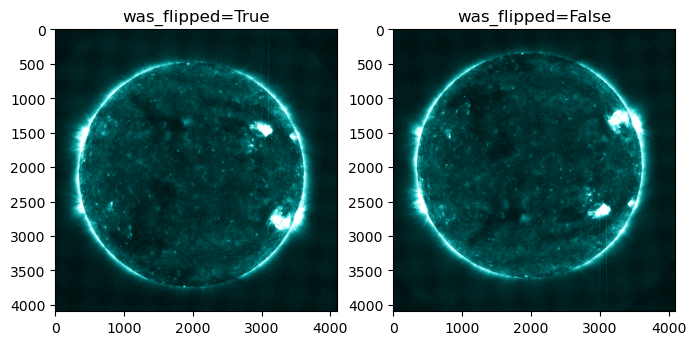

In [8]:
sample_a = None
sample_b = None
for _ in range(50):  # keep drawing until you get one of each
    s = train_dataset.__getitem__(0)
    if s['was_flipped'] and sample_a is None:
        sample_a = s
    if not s['was_flipped'] and sample_b is None:
        sample_b = s
    if sample_a is not None and sample_b is not None:
        break

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
frame_a = train_dataset.inverse_transform_data(sample_a['ts'][:, 1, ...])[0]
frame_b = train_dataset.inverse_transform_data(sample_b['ts'][:, 1, ...])[0]
axes[0].imshow(frame_a, cmap='sdoaia131', vmin=0, vmax=np.percentile(frame_a[frame_a != 0], 99))
axes[0].set_title(f"was_flipped={sample_a['was_flipped']}")
axes[1].imshow(frame_b, cmap='sdoaia131', vmin=0, vmax=np.percentile(frame_b[frame_b != 0], 99))
axes[1].set_title(f"was_flipped={sample_b['was_flipped']}")
plt.show()

In [6]:
for i in range(3):
    sample = train_dataset.__getitem__(0)
    print(f"call {i}: was_flipped={sample['was_flipped']}")

call 0: was_flipped=False


call 1: was_flipped=False


call 2: was_flipped=True


## checking flips: check 2
- simply combining two check 1 into one.

flip_probability=0.5
observed: 4/5 flipped (80.0%)


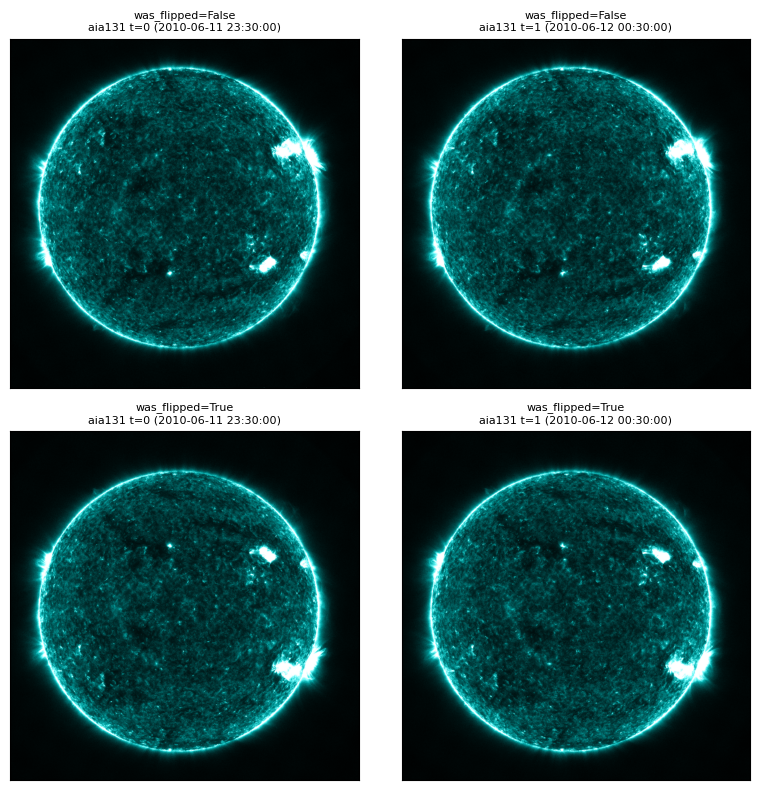

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Empirical flip rate over many draws of the same index
n_draws = 5
flip_count = 0
sample_flipped = None
sample_not_flipped = None
for i in range(n_draws):
    s = train_dataset.__getitem__(0)
    if s['was_flipped']:
        flip_count += 1
        if sample_flipped is None:
            sample_flipped = s
    else:
        if sample_not_flipped is None:
            sample_not_flipped = s

print(f"flip_probability={train_dataset.flip_probability}")
print(f"observed: {flip_count}/{n_draws} flipped ({flip_count/n_draws:.1%})")
assert sample_flipped is not None and sample_not_flipped is not None, \
    "didn't see both outcomes in n_draws -- raise n_draws or check flip_probability"

# 2. Plot both input timesteps for one flipped example and one unflipped example
channel_idx = 1  # aia131
channel = cfg.data.channels[channel_idx]
anchor_time = pd.Timestamp(sample_flipped['ds_index'])
frame_timestamps = [anchor_time + pd.Timedelta(minutes=off) for off in cfg.data.time_delta_input_minutes]
n_timesteps = sample_flipped['ts'].shape[1]

fig, axes = plt.subplots(2, n_timesteps, figsize=(4 * n_timesteps, 8))
for row, (sample, row_label) in enumerate(
    [(sample_not_flipped, "was_flipped=False"), (sample_flipped, "was_flipped=True")]
):
    for t in range(n_timesteps):
        frame = train_dataset.inverse_transform_data(sample['ts'][:, t, ...])[channel_idx]
        lim = np.percentile(frame[frame != 0], 99)
        ax = axes[row, t]
        ax.imshow(frame, cmap=f'sdo{channel}', vmin=0, vmax=lim)
        ax.set_title(f"{row_label}\n{channel} t={t} ({frame_timestamps[t]})", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## trying for peak time now:

In [15]:
item = train_dataset.__getitem__(0)

Input timestamps: [Timestamp('2010-06-11 22:57:00'), Timestamp('2010-06-11 23:57:00')]
Forecast timestamps: [Timestamp('2010-06-12 00:57:00')]


[input]  t=0 timestamp=2010-06-11 22:57:00 min=0.0000 max=184.1137 mean=0.6011


[input]  t=1 timestamp=2010-06-11 23:57:00 min=0.0000 max=196.2283 mean=0.6067


[ground_truth] l=0 timestamp=2010-06-12 00:57:00 min=0.0000 max=619.2961 mean=0.6233


/tmp/ipykernel_1305/615703746.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


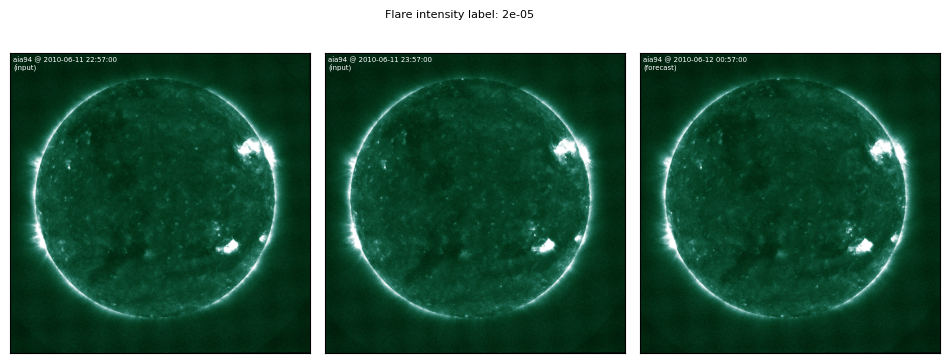

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

anchor_time = pd.Timestamp(item['ds_index'])
input_offsets = cfg.data.time_delta_input_minutes
frame_timestamps = [anchor_time + pd.Timedelta(minutes=off) for off in input_offsets]
print("Input timestamps:", frame_timestamps)

target_offsets = cfg.data.time_delta_target_minutes
n_lead_steps = item['forecast'].shape[1]
target_timestamps = [anchor_time + pd.Timedelta(minutes=target_offsets * (l + 1)) for l in range(n_lead_steps)]
print("Forecast timestamps:", target_timestamps)

n = 0
channel_order = cfg.data.channels
channel = channel_order[n]
n_timesteps = item['ts'].shape[1]

n_cols = n_timesteps + n_lead_steps
fig = plt.figure(figsize=np.array([4 * n_cols, 4]), dpi=100)
gs = gridspec.GridSpec(1, n_cols, figure=fig, wspace=0.05, hspace=0)

def plot_frame(ax, plot_ts, label):
    if 'hmi' not in channel:
        lim = np.percentile(plot_ts[plot_ts != 0], 99)
        ax.imshow(plot_ts, cmap=f'sdo{channel}', vmin=0, vmax=lim)
        font_color = 'w'
    else:
        font_color = 'k'
        lim = 1000
        if "_v" not in channel:
            ax.imshow(plot_ts, cmap='hmimag', vmin=-lim, vmax=lim)
        else:
            ax.imshow(plot_ts, cmap='coolwarm', vmin=-lim, vmax=lim)
    ax.text(0.01, 0.99, label, transform=ax.transAxes,
            horizontalalignment='left', verticalalignment='top',
            color=font_color, fontsize=5)
    ax.set_xticks([])
    ax.set_yticks([])

for t in range(n_timesteps):
    ts_frame = train_dataset.inverse_transform_data(item['ts'][:, t, ...])
    plot_ts = ts_frame[n, ...]
    print(f"[input]  t={t} timestamp={frame_timestamps[t]} min={plot_ts.min():.4f} max={plot_ts.max():.4f} mean={plot_ts.mean():.4f}")
    ax = fig.add_subplot(gs[0, t])
    plot_frame(ax, plot_ts, f"{channel} @ {frame_timestamps[t]}\n(input)")

for l in range(n_lead_steps):
    forecast_frame = train_dataset.inverse_transform_data(item['forecast'][:, l, ...])
    plot_ts = forecast_frame[n, ...]
    print(f"[ground_truth] l={l} timestamp={target_timestamps[l]} min={plot_ts.min():.4f} max={plot_ts.max():.4f} mean={plot_ts.mean():.4f}")
    ax = fig.add_subplot(gs[0, n_timesteps + l])
    plot_frame(ax, plot_ts, f"{channel} @ {target_timestamps[l]}\n(forecast)")

fig.suptitle(f"Flare intensity label: {float(item['ground_truth']):.4g}", fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
import pandas as pd

flare_catalog = pd.read_csv(cfg.data.flare_index_path)
flare_catalog['start_time'] = pd.to_datetime(flare_catalog['start_time'])
flare_catalog['end_time'] = pd.to_datetime(flare_catalog['end_time'])

event_time = pd.Timestamp(item['ds_index'])

match = flare_catalog[
    (flare_catalog['start_time'] <= event_time) &
    (flare_catalog['end_time'] >= event_time)
]

if not match.empty:
    print(f"Flare in progress at {event_time}:")
    print(match[['start_time', 'peak_time', 'end_time', 'GOES_class']])
else:
    print(f"No flare in progress at {event_time} (nearest events below):")
    nearest = flare_catalog.iloc[(flare_catalog['start_time'] - event_time).abs().argsort()[:3]]
    print(nearest[['start_time', 'peak_time', 'end_time', 'GOES_class']])

Flare in progress at 2010-06-12 00:57:00:
               start_time            peak_time            end_time GOES_class
49292 2010-06-12 00:30:00  2010-06-12T00:57:00 2010-06-12 01:02:00       M2.0


## looking for x-class flares for visual inspection

In [1]:
train_dataset = flare_Dataset(
    index_path=cfg.data.train_data_path,
    time_delta_input_minutes=cfg.data.time_delta_input_minutes,
    time_delta_target_minutes=cfg.data.time_delta_target_minutes,
    n_input_timestamps=cfg.model.time_embedding.time_dim,
    rollout_steps=cfg.rollout_steps,
    channels=cfg.data.channels,
    drop_hmi_probability=cfg.drop_hmi_probability,
    use_latitude_in_learned_flow=cfg.use_latitude_in_learned_flow,
    scalers=scalers,
    phase="train",
    s3_mode=cfg.data.s3_mode,
    s3_storage_options={"anon": cfg.data.s3_anon},
    s3_cache_dir=cfg.data.s3_cache_dir,
    return_surya_stack=True,
    max_number_of_samples=None,   # <- was 6, no cap so we can see the X-class events
    ds_flare_index_path=cfg.data.flare_index_path,
    ds_time_column=cfg.data.ds_time_column,
    ds_time_tolerance=cfg.data.ds_time_tolerance,
    ds_match_direction=cfg.data.ds_match_direction,
    flip_probability=0.5,
)
print(len(train_dataset))  # sanity check — should be way more than 6 now

NameError: name 'flare_Dataset' is not defined

In [20]:
import numpy as np

x_class_mask = train_dataset.df_valid_indices['GOES_class'].str.startswith('X')
positions = np.where(x_class_mask.values)[0]
print(f"found {len(positions)} X-class matches")
print(train_dataset.df_valid_indices.iloc[positions][['GOES_class', 'ds_index']])

found 38 X-class matches
                    GOES_class            ds_index
valid_indices                                     
2011-03-09 23:12:00       X1.5 2011-03-09 23:23:00
2011-08-09 08:00:00       X6.9 2011-08-09 08:05:00
2011-09-06 22:12:00       X2.1 2011-09-06 22:20:00
2011-09-07 22:36:00       X1.8 2011-09-07 22:38:00
2011-09-22 10:48:00       X1.4 2011-09-22 11:01:00
2011-11-03 20:24:00       X1.9 2011-11-03 20:27:00
2013-05-13 02:12:00       X1.7 2013-05-13 02:17:00
2013-05-13 16:00:00       X2.8 2013-05-13 16:05:00
2013-05-14 01:00:00       X3.2 2013-05-14 01:11:00
2013-05-15 01:48:00       X1.2 2013-05-15 01:48:00
2013-10-25 08:00:00       X1.7 2013-10-25 08:01:00
2013-10-25 15:00:00       X2.1 2013-10-25 15:03:00
2013-10-28 02:00:00       X1.0 2013-10-28 02:03:00
2013-10-29 21:48:00       X2.3 2013-10-29 21:54:00
2013-11-05 22:00:00       X3.3 2013-11-05 22:12:00
2013-11-08 04:24:00       X1.1 2013-11-08 04:26:00
2013-11-10 05:12:00       X1.1 2013-11-10 05:14:00
2013-1

In [26]:
idx = positions[34]   # or pick a specific row from the printout above
item = train_dataset.__getitem__(idx)
print(train_dataset.df_valid_indices.iloc[idx][['GOES_class', 'ds_index']])

GOES_class                   X1.3
ds_index      2017-09-07 14:36:00
Name: 2017-09-07 14:36:00, dtype: object


In [27]:
import pandas as pd

flare_catalog = pd.read_csv(cfg.data.flare_index_path)
flare_catalog['start_time'] = pd.to_datetime(flare_catalog['start_time'])
flare_catalog['end_time'] = pd.to_datetime(flare_catalog['end_time'])

event_time = pd.Timestamp(item['ds_index'])

match = flare_catalog[
    (flare_catalog['start_time'] <= event_time) &
    (flare_catalog['end_time'] >= event_time)
]

if not match.empty:
    print(f"Flare in progress at {event_time}:")
    print(match[['start_time', 'peak_time', 'end_time', 'GOES_class']])
else:
    print(f"No flare in progress at {event_time} (nearest events below):")
    nearest = flare_catalog.iloc[(flare_catalog['start_time'] - event_time).abs().argsort()[:3]]
    print(nearest[['start_time', 'peak_time', 'end_time', 'GOES_class']])

Flare in progress at 2017-09-07 14:36:00:
               start_time            peak_time            end_time GOES_class
57766 2017-09-07 14:20:00  2017-09-07T14:36:00 2017-09-07 14:55:00       X1.3


Input timestamps: [Timestamp('2017-09-07 12:36:00'), Timestamp('2017-09-07 13:36:00')]
WILL FORECAST timestamp: [Timestamp('2017-09-07 14:36:00')]


[input]  t=0 timestamp=2017-09-07 12:36:00 min=0.0000 max=935.0353 mean=0.8116


[input]  t=1 timestamp=2017-09-07 13:36:00 min=0.0000 max=439.9757 mean=0.7540


[ground_truth] l=0 timestamp=2017-09-07 14:36:00 min=0.0000 max=16383.0010 mean=2.0563


/tmp/ipykernel_1305/2071090896.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


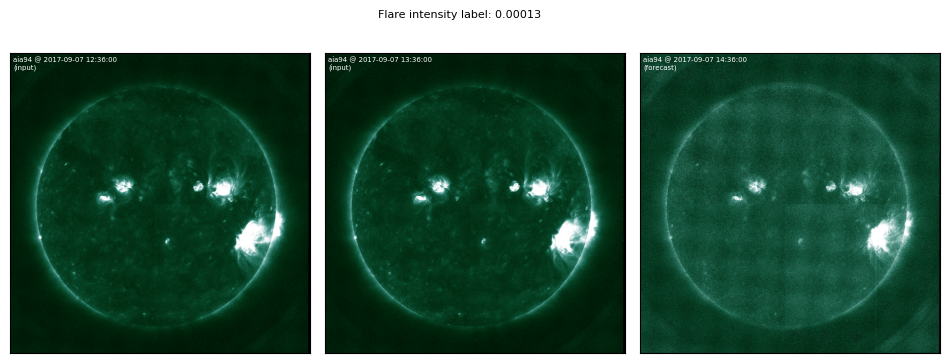

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

anchor_time = pd.Timestamp(item['ds_index'])
input_offsets = cfg.data.time_delta_input_minutes
frame_timestamps = [anchor_time + pd.Timedelta(minutes=off) for off in input_offsets]
print("Input timestamps:", frame_timestamps)

target_offsets = cfg.data.time_delta_target_minutes
n_lead_steps = item['forecast'].shape[1]
target_timestamps = [anchor_time + pd.Timedelta(minutes=target_offsets * (l + 1)) for l in range(n_lead_steps)]
print("WILL FORECAST timestamp:", target_timestamps)

n = 0
channel_order = cfg.data.channels
channel = channel_order[n]
n_timesteps = item['ts'].shape[1]

n_cols = n_timesteps + n_lead_steps
fig = plt.figure(figsize=np.array([4 * n_cols, 4]), dpi=100)
gs = gridspec.GridSpec(1, n_cols, figure=fig, wspace=0.05, hspace=0)

def plot_frame(ax, plot_ts, label):
    if 'hmi' not in channel:
        lim = np.percentile(plot_ts[plot_ts != 0], 99)
        ax.imshow(plot_ts, cmap=f'sdo{channel}', vmin=0, vmax=lim)
        font_color = 'w'
    else:
        font_color = 'k'
        lim = 1000
        if "_v" not in channel:
            ax.imshow(plot_ts, cmap='hmimag', vmin=-lim, vmax=lim)
        else:
            ax.imshow(plot_ts, cmap='coolwarm', vmin=-lim, vmax=lim)
    ax.text(0.01, 0.99, label, transform=ax.transAxes,
            horizontalalignment='left', verticalalignment='top',
            color=font_color, fontsize=5)
    ax.set_xticks([])
    ax.set_yticks([])

for t in range(n_timesteps):
    ts_frame = train_dataset.inverse_transform_data(item['ts'][:, t, ...])
    plot_ts = ts_frame[n, ...]
    print(f"[input]  t={t} timestamp={frame_timestamps[t]} min={plot_ts.min():.4f} max={plot_ts.max():.4f} mean={plot_ts.mean():.4f}")
    ax = fig.add_subplot(gs[0, t])
    plot_frame(ax, plot_ts, f"{channel} @ {frame_timestamps[t]}\n(input)")

for l in range(n_lead_steps):
    forecast_frame = train_dataset.inverse_transform_data(item['forecast'][:, l, ...])
    plot_ts = forecast_frame[n, ...]
    print(f"[ground_truth] l={l} timestamp={target_timestamps[l]} min={plot_ts.min():.4f} max={plot_ts.max():.4f} mean={plot_ts.mean():.4f}")
    ax = fig.add_subplot(gs[0, n_timesteps + l])
    plot_frame(ax, plot_ts, f"{channel} @ {target_timestamps[l]}\n(forecast)")

fig.suptitle(f"Flare intensity label: {float(item['ground_truth']):.4g}", fontsize=8)
plt.tight_layout()
plt.show()

In [29]:
print("input t0 vs input t1 identical?", np.array_equal(item['ts'][:, 0], item['ts'][:, 1]))
print("input t1 vs forecast identical?", np.array_equal(item['ts'][:, 1], item['forecast'][:, 0]))

input t0 vs input t1 identical? False
input t1 vs forecast identical? False


In [30]:
reference_timestep = train_dataset.valid_indices[idx]
print("reference_timestep (actually used to load frames):", reference_timestep)
print("ds_index (flare catalog label, may differ):", item['ds_index'])

input_offsets = cfg.data.time_delta_input_minutes          # [-120, -60]
target_offset = cfg.data.time_delta_target_minutes          # 0

true_timesteps = [reference_timestep + pd.Timedelta(minutes=m) for m in input_offsets]
true_timesteps.append(reference_timestep + pd.Timedelta(minutes=target_offset))

for ts in true_timesteps:
    print(ts, "->", train_dataset.index.loc[ts, "path"])

reference_timestep (actually used to load frames): 2017-09-07 14:36:00
ds_index (flare catalog label, may differ): 2017-09-07T14:36:00
2017-09-07 12:36:00 -> s3://nasa-surya-bench/2017/09/20170907_1236.nc
2017-09-07 13:36:00 -> s3://nasa-surya-bench/2017/09/20170907_1336.nc
2017-09-07 14:36:00 -> s3://nasa-surya-bench/2017/09/20170907_1436.nc


#### still hard to see -- running difference image to check 

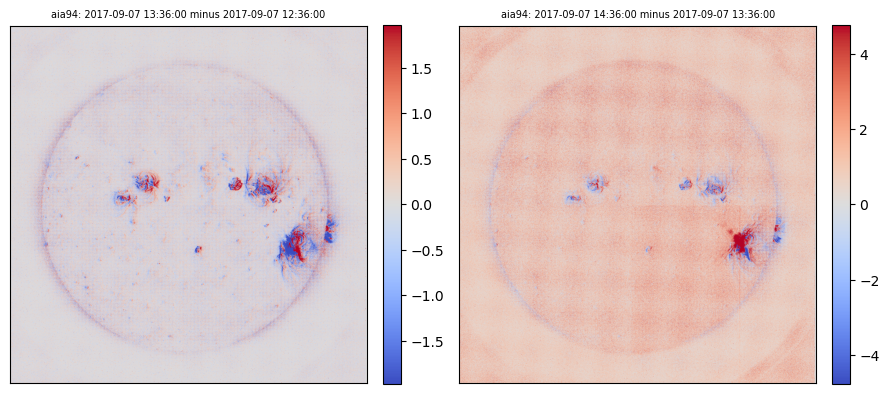

In [31]:
import numpy as np
import matplotlib.pyplot as plt

n = 0  # channel index — matches the channel used in the earlier plotting cell
channel = cfg.data.channels[n]

# Use the true reference timestep (not ds_index) for accurate labels
reference_timestep = train_dataset.valid_indices[idx]
input_offsets = cfg.data.time_delta_input_minutes
target_offset = cfg.data.time_delta_target_minutes
t0_time = reference_timestep + pd.Timedelta(minutes=input_offsets[0])
t1_time = reference_timestep + pd.Timedelta(minutes=input_offsets[1])
fc_time = reference_timestep + pd.Timedelta(minutes=target_offset)

frame_t0 = train_dataset.inverse_transform_data(item['ts'][:, 0, ...])[n]
frame_t1 = train_dataset.inverse_transform_data(item['ts'][:, 1, ...])[n]
frame_fc = train_dataset.inverse_transform_data(item['forecast'][:, 0, ...])[n]

diff_inputs = frame_t1 - frame_t0        # t1 - t0
diff_forecast = frame_fc - frame_t1      # forecast - t1

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), dpi=100)

for ax, diff, title in zip(
    axes,
    [diff_inputs, diff_forecast],
    [f"{channel}: {t1_time} minus {t0_time}",
     f"{channel}: {fc_time} minus {t1_time}"],
):
    lim = np.percentile(np.abs(diff), 99)
    im = ax.imshow(diff, cmap='coolwarm', vmin=-lim, vmax=lim)
    ax.set_title(title, fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Input timestamps: [Timestamp('2017-09-07 12:36:00'), Timestamp('2017-09-07 13:36:00')]
WILL FORECAST timestamp: [Timestamp('2017-09-07 14:36:00')]


[input]  t=0 timestamp=2017-09-07 12:36:00 min=0.0000 max=935.0353 mean=0.8116


[input]  t=1 timestamp=2017-09-07 13:36:00 min=0.0000 max=439.9757 mean=0.7540


[ground_truth] l=0 timestamp=2017-09-07 14:36:00 min=0.0000 max=16383.0010 mean=2.0563


/tmp/ipykernel_1305/3832773984.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


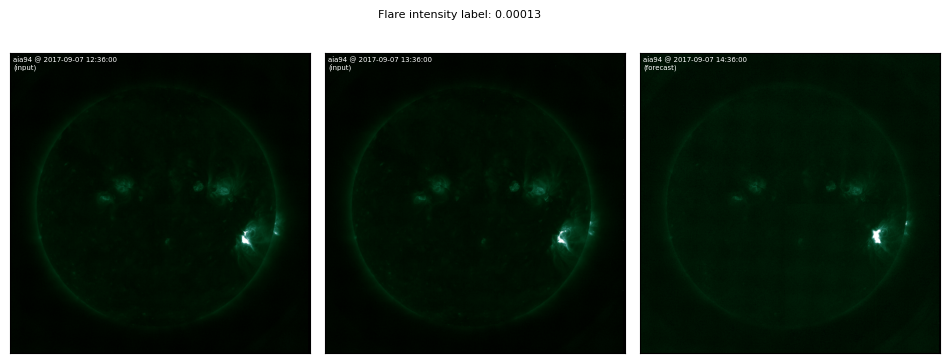

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

anchor_time = pd.Timestamp(item['ds_index'])
input_offsets = cfg.data.time_delta_input_minutes
frame_timestamps = [anchor_time + pd.Timedelta(minutes=off) for off in input_offsets]
print("Input timestamps:", frame_timestamps)

target_offsets = cfg.data.time_delta_target_minutes
n_lead_steps = item['forecast'].shape[1]
target_timestamps = [anchor_time + pd.Timedelta(minutes=target_offsets * (l + 1)) for l in range(n_lead_steps)]
print("WILL FORECAST timestamp:", target_timestamps)

n = 0
channel_order = cfg.data.channels
channel = channel_order[n]
n_timesteps = item['ts'].shape[1]

n_cols = n_timesteps + n_lead_steps
fig = plt.figure(figsize=np.array([4 * n_cols, 4]), dpi=100)
gs = gridspec.GridSpec(1, n_cols, figure=fig, wspace=0.05, hspace=0)

def plot_frame(ax, plot_ts, label):
    if 'hmi' not in channel:
        lim = np.percentile(plot_ts[plot_ts != 0], 99)*10
        ax.imshow(plot_ts, cmap=f'sdo{channel}', vmin=0, vmax=lim)
        font_color = 'w'
    else:
        font_color = 'k'
        lim = np.percentile(plot_ts[plot_ts != 0], 99)*10
        if "_v" not in channel:
            ax.imshow(plot_ts, cmap='hmimag', vmin=-lim, vmax=lim)
        else:
            ax.imshow(plot_ts, cmap='coolwarm', vmin=-lim, vmax=lim)
    ax.text(0.01, 0.99, label, transform=ax.transAxes,
            horizontalalignment='left', verticalalignment='top',
            color=font_color, fontsize=5)
    ax.set_xticks([])
    ax.set_yticks([])

for t in range(n_timesteps):
    ts_frame = train_dataset.inverse_transform_data(item['ts'][:, t, ...])
    plot_ts = ts_frame[n, ...]
    print(f"[input]  t={t} timestamp={frame_timestamps[t]} min={plot_ts.min():.4f} max={plot_ts.max():.4f} mean={plot_ts.mean():.4f}")
    ax = fig.add_subplot(gs[0, t])
    plot_frame(ax, plot_ts, f"{channel} @ {frame_timestamps[t]}\n(input)")

for l in range(n_lead_steps):
    forecast_frame = train_dataset.inverse_transform_data(item['forecast'][:, l, ...])
    plot_ts = forecast_frame[n, ...]
    print(f"[ground_truth] l={l} timestamp={target_timestamps[l]} min={plot_ts.min():.4f} max={plot_ts.max():.4f} mean={plot_ts.mean():.4f}")
    ax = fig.add_subplot(gs[0, n_timesteps + l])
    plot_frame(ax, plot_ts, f"{channel} @ {target_timestamps[l]}\n(forecast)")

fig.suptitle(f"Flare intensity label: {float(item['ground_truth']):.4g}", fontsize=8)
plt.tight_layout()
plt.show()